In [ ]:
#step 1: Load Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import root_mean_squared_error, r2_score
import os
import warnings
warnings.filterwarnings('ignore')
print('All Module Loaded Successfully!')

All Module Loaded Successfully!


In [ ]:
url="https://raw.githubusercontent.com/AKasCODE/Linear-Regression/refs/heads/main/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_2448.csv"
df=pd.read_csv(url, skiprows=4)

In [ ]:
df.shape

(265, 71)

In [ ]:
df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [ ]:
df_china=df[df['Country Name']=='China']
df_china=df_china.drop(['Country Name','Country Code','Indicator Name','Indicator Code','Unnamed: 70'],axis=1)
df_china

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
40,89.715075,75.965501,71.061685,74.468154,85.661107,98.668169,104.506464,96.761448,91.645458,100.308139,...,8254.868593,8979.676527,10085.663815,10342.900952,10627.463799,12887.435724,12970.605641,12951.17824,13293.116227,13861.970224


In [ ]:
df_china=df_china.melt(var_name='Year', value_name='Per_Capita')

In [ ]:
df_china.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year        66 non-null     object 
 1   Per_Capita  66 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


In [ ]:
df_china['Year']=df_china['Year'].astype(int)

In [ ]:
X=df_china['Year']
y=df_china['Per_Capita']
y

,Per_Capita
0,89.715075
1,75.965501
2,71.061685
3,74.468154
4,85.661107
...,...
61,12887.435724
62,12970.605641
63,12951.178240
64,13293.116227


In [ ]:
X

,Year
0,1960
1,1961
2,1962
3,1963
4,1964
...,...
61,2021
62,2022
63,2023
64,2024


In [ ]:
df_china.corr()

,Year,Per_Capita
Year,1.000000,0.813912
Per_Capita,0.813912,1.000000


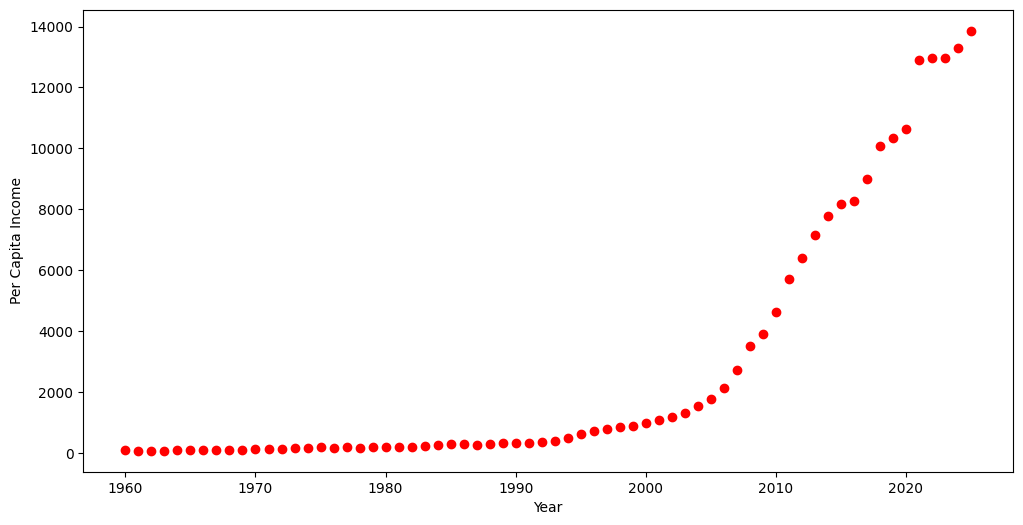

In [ ]:
plt.figure(figsize =(12,6))
plt.scatter(X,y, color='r')
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.show()

In [31]:
new_df = df_china[df_china['Year']>=2000]
X=new_df[['Year']]
y=new_df['Per_Capita']

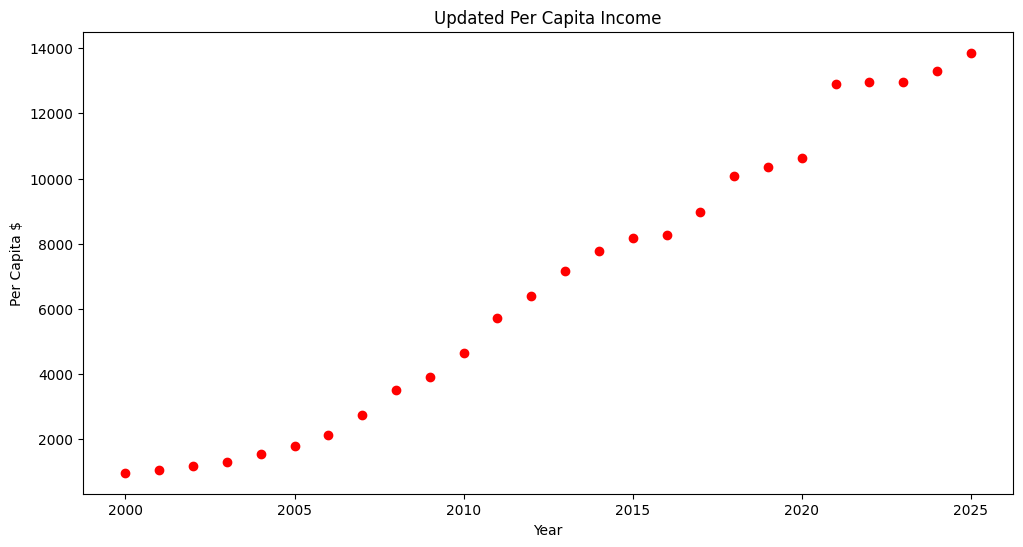

In [32]:
# Plot Per Capita Income vs Year
plt.figure(figsize =(12,6))
plt.title("Updated Per Capita Income")
plt.scatter(X,y, color='r')
plt.xlabel("Year")
plt.ylabel("Per Capita $")
plt.show()

In [33]:
#Model building using Linear Regression
model= LinearRegression() #object creation
model.fit(X,y)

LinearRegression()

In [34]:
y_pred=model.predict(X)
y_pred

array([ -524.3427496 ,    53.59161932,   631.52598823,  1209.46035715,
        1787.39472606,  2365.32909498,  2943.26346389,  3521.19783281,
        4099.13220172,  4677.06657064,  5255.00093955,  5832.93530847,
        6410.86967738,  6988.8040463 ,  7566.73841521,  8144.67278413,
        8722.60715304,  9300.54152196,  9878.47589087, 10456.41025979,
       11034.3446287 , 11612.27899762, 12190.21336653, 12768.14773545,
       13346.08210436, 13924.01647328])

In [35]:
df_comp= new_df.copy()
df_comp['Model_y']= y_pred
df_comp['Error']=df_comp['Model_y'] - df_comp.iloc[:,-2]
df_comp

,Year,Per_Capita,Model_y,Error
40,2000,969.199514,-524.342750,-1493.542263
41,2001,1065.405976,53.591619,-1011.814356
42,2002,1163.559577,631.525988,-532.033589
43,2003,1306.972454,1209.460357,-97.512097
44,2004,1530.927262,1787.394726,256.467464
45,2005,1777.644968,2365.329095,587.684127
46,2006,2129.256970,2943.263464,814.006494
47,2007,2734.727099,3521.197833,786.470734
48,2008,3523.443021,4099.132202,575.689181
49,2009,3898.244592,4677.066571,778.821979


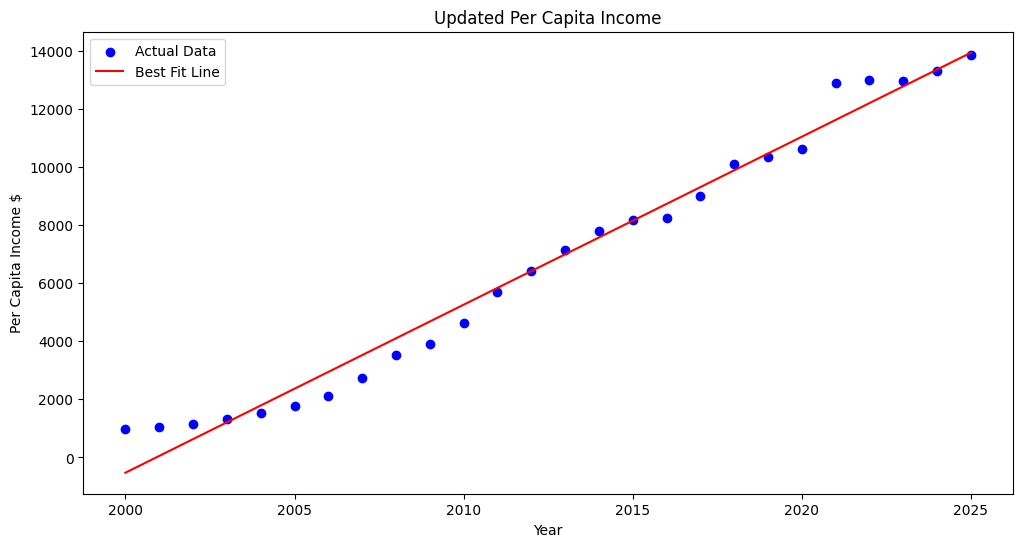

In [36]:
# Model best fit line
plt.figure(figsize =(12,6))
plt.title("Updated Per Capita Income")
plt.scatter(X,y, color='b', label='Actual Data')
plt.plot(X,y_pred, color='r', label='Best Fit Line')
plt.xlabel("Year")
plt.ylabel("Per Capita Income $")
plt.legend()
plt.show()

In [37]:
#Next 5 years Per-Capita Forecasting
next_5_year=[[i] for i in range(2026,2031)]
model_ans= model.predict(next_5_year)
forecast_df=pd.DataFrame({'Next-5-year':next_5_year,'Prediction-Per-Capital':model_ans})
forecast_df

,Next-5-year,Prediction-Per-Capital
0,[2026],14501.950842
1,[2027],15079.885211
2,[2028],15657.819580
3,[2029],16235.753949
4,[2030],16813.688318


In [38]:
# Model Evaluation
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")

R² Score : 0.9810
MAE      : 460.30
RMSE     : 603.70


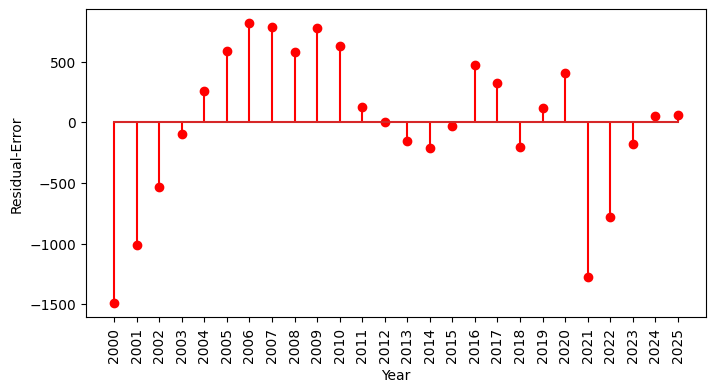

In [41]:
# Residual Plot: to identify model mistakes
plt.figure(figsize=(8,4))
plt.stem(df_comp['Error'], linefmt='r-')
plt.xticks(range(26), df_comp['Year'], rotation=90)
plt.xlabel("Year")
plt.ylabel("Residual-Error")
plt.show()

#Conclusion
A Linear Regression model was trained to forecast China's per capita income using historical data. The model achieved an R² score of 0.9810, indicating that it explains 98.1% of the variance in the dataset. The MAE and RMSE values of 460.30 and 603.70 respectively indicate relatively low prediction errors. The residual plot shows no strong systematic pattern, suggesting that the linear model provides a reasonable fit. Based on the trained model, forecasts for the next five years (2026–2030) indicate a continued upward trend in per capita income.